### Pairs trading with 5 assets

Overall, the exercise suggests that even a very simple cross-sectional stat-arb construction can improve risk adjusted returns with respect to a simple 50/50 buy & hold benchmark, which is notable given that short-horizon relative-value signals are widely researched and heavily contested across the industry. The more important takeaway is that a basic, crowded formulation still appears to retain some value, implying that careful improvements such as better neutralization, transaction cost modeling, execution lags, and alternative “less-contested” feature spaces—could bring more meaningful incremental performance.

In [57]:
import yfinance as yf
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

### Download tickers

In [58]:
assets = ['JPM', 'BAC', 'C', 'GS', 'MS']

data = yf.download(tickers=assets, interval='1d')[['Close', 'Volume']]

data = data.dropna()

close = data['Close']
volume = data['Volume']

print(data.head())
print(data.tail())

[*********************100%***********************]  5 of 5 completed

Price           Close                                                Volume  \
Ticker            BAC           C         GS        JPM         MS      BAC   
Date                                                                          
1999-05-04  17.656445  187.751312  48.696564  25.592781  23.754930  6678400   
1999-05-05  17.781794  189.050598  47.831623  24.951031  24.027443  8095800   
1999-05-06  17.421448  181.417160  47.009907  24.134232  22.982777  6730000   
1999-05-07  17.625122  182.229202  51.291389  24.387054  24.390812  5759000   
1999-05-10  17.327446  185.315063  48.912815  24.581516  23.709507  6041200   

Price                                                     
Ticker              C          GS        JPM          MS  
Date                                                      
1999-05-04  1530920.0  22320900.0  4670850.0  10458400.0  
1999-05-05  2100720.0   7565700.0  6652650.0   8413800.0  
1999-05-06  1801000.0   2905700.0  7305150.0   5649600.0  
1999-05-07  1

### Obtaining returns

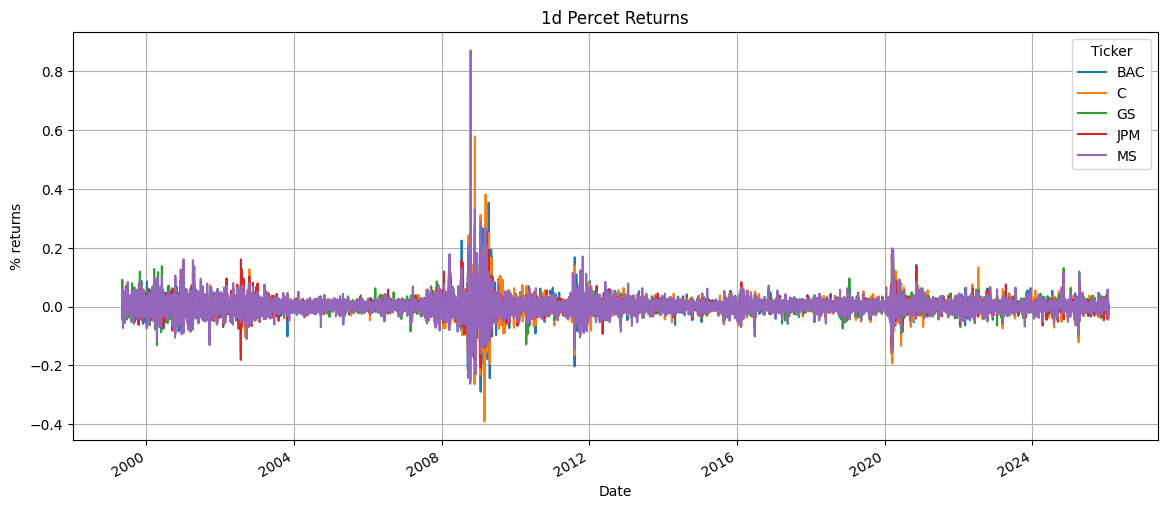

In [59]:
returns = close.pct_change()

returns.plot(grid=True, figsize=(14,6))
plt.title("1d Percet Returns")
plt.ylabel('% returns')
plt.show()

### Extracting signals 

this is done based on how much their individual returns deviate from the average on a 5 day rolling period and that translates into the weights

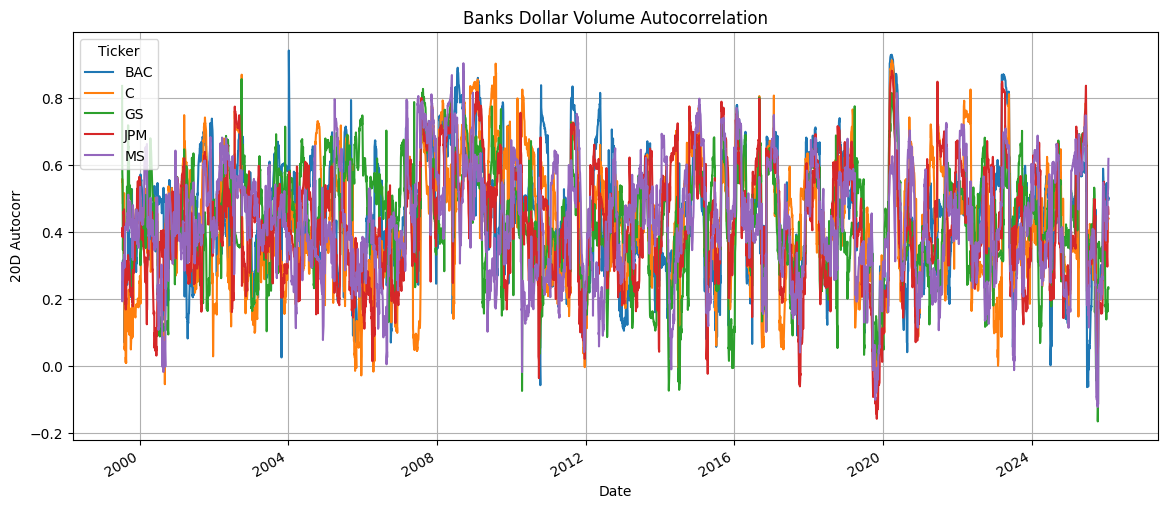

In [60]:
banks_autocorr = volume.rolling(50).apply(lambda x: x.autocorr())

banks_autocorr.plot(grid=True, figsize=(14,6))
plt.title('Banks Dollar Volume Autocorrelation')
plt.ylabel('20D Autocorr')
plt.show()

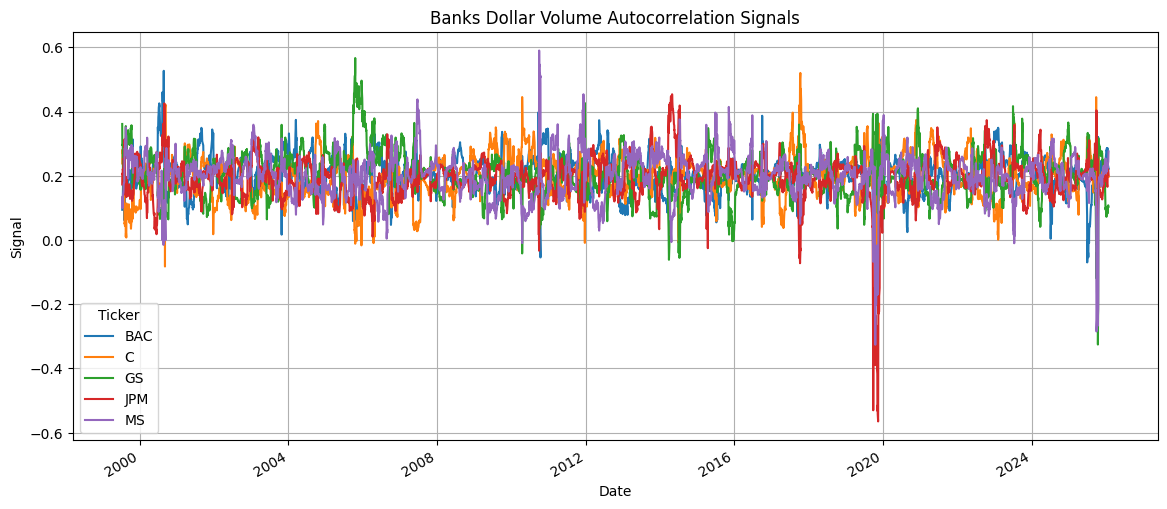

In [61]:
signal = -(
    banks_autocorr.subtract(
    banks_autocorr.mean(axis=1),
    axis=0
    )
)

signal = (
    banks_autocorr.divide(
    banks_autocorr.abs().sum(axis=1),
    axis=0
    )
) 

signal.plot(grid=True, figsize=(14,6))
plt.title('Banks Dollar Volume Autocorrelation Signals')
plt.ylabel('Signal')
plt.show()

### Returns without reinvestments

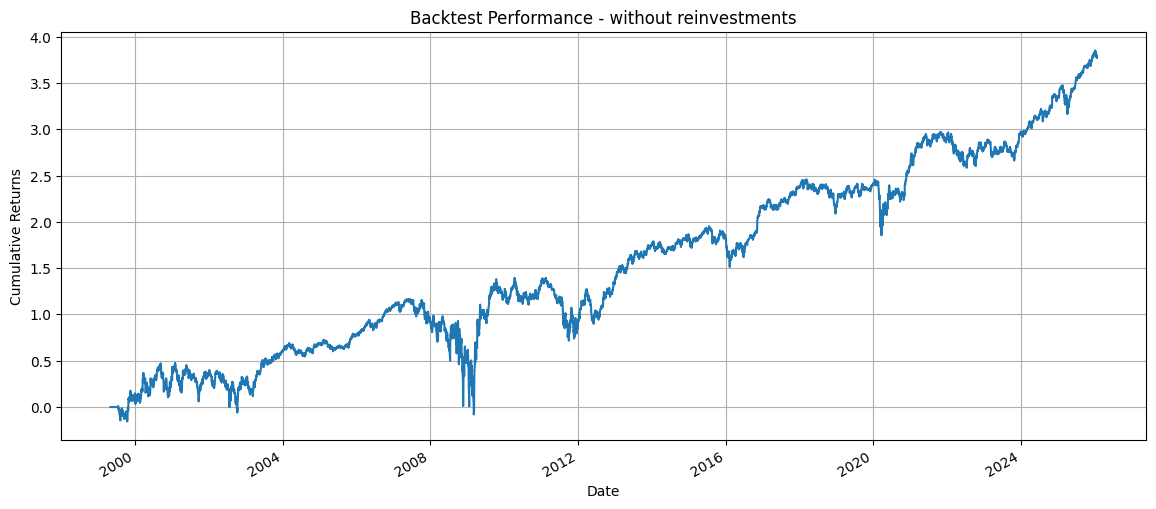

In [67]:
performance = signal.shift(2).multiply(returns).sum(axis=1).cumsum()

performance.plot(grid=True, figsize=(14, 6))
plt.title('Backtest Performance - without reinvestments')
plt.ylabel('Cumulative Returns')
plt.show()

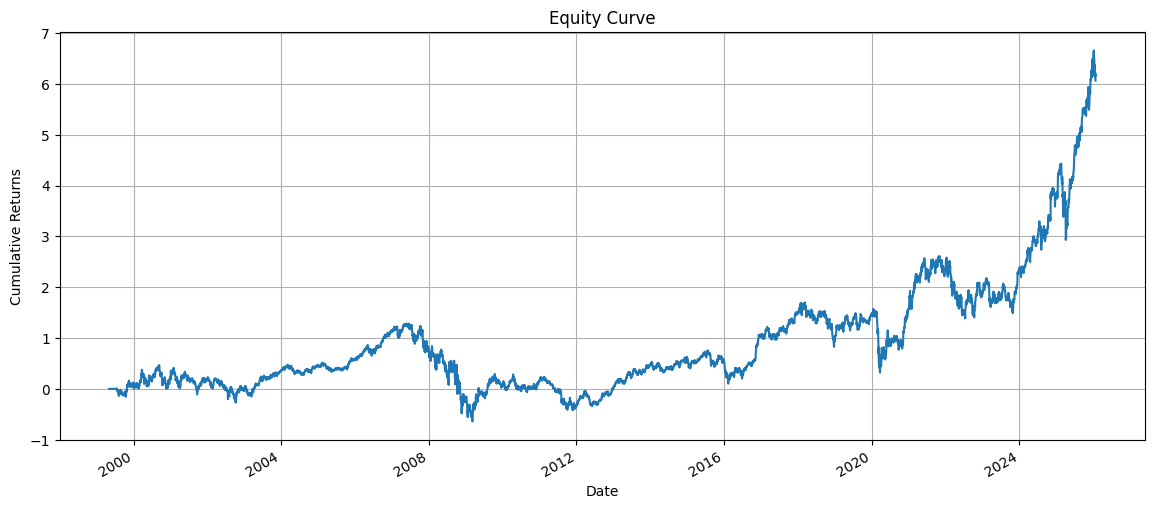

In [68]:
daily_pnl = signal.shift(2).multiply(returns).sum(1)
equity_curve = (1 + daily_pnl).cumprod() - 1

equity_curve.plot(grid=True, figsize=(14, 6))
plt.title('Equity Curve')
plt.ylabel('Cumulative Returns')
plt.show()

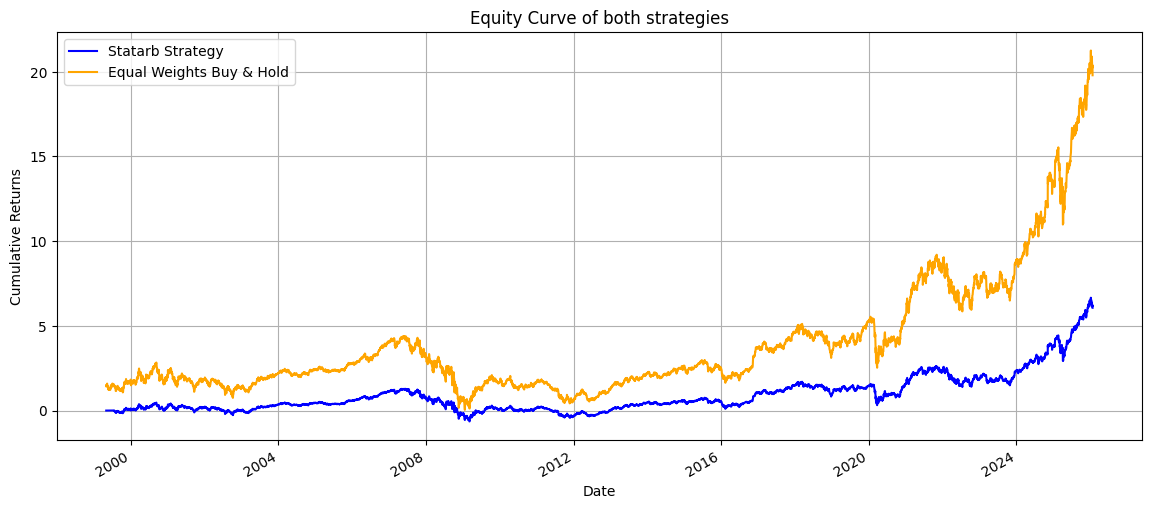

In [69]:
px = (1 + returns).cumprod() 
equal_weights_bh = (0.5 * px.iloc[:,0] + 0.5 * px.iloc[:,1] + 0.5 * px.iloc[:,2] + 0.5 * px.iloc[:,3] + 0.5 * px.iloc[:,4]) - 1

df = pd.concat([equity_curve.rename('Statarb Strategy'), equal_weights_bh.rename('Equal Weights Buy & Hold')], axis=1)

df.plot(grid=True, figsize=(14, 6), color=["blue", "orange"],)
plt.title('Equity Curve of both strategies')
plt.ylabel('Cumulative Returns')
plt.show()

### Performance Stats - Statarb Strategy

In [70]:
total_return = equity_curve.iloc[-1]
annual_vol = daily_pnl.std() * np.sqrt(252)
sharpe = (daily_pnl.mean() / daily_pnl.std()) * np.sqrt(252)

print('Statarb')
print('Total return: ', total_return)
print('Volatility: ', annual_vol)
print('Sharpe Ratio: ', sharpe)

Statarb
Total return:  6.066764468741189
Volatility:  0.3713485729926776
Sharpe Ratio:  0.38087455307721046


### Performance Stats - 50/50 Buy & Hold

In [66]:
total_return_bh = equal_weights_bh.iloc[-1]
bh_daily_ret = equal_weights_bh.pct_change().dropna()
annual_vol_bh = bh_daily_ret.std() * np.sqrt(252)
sharpe_bh = (bh_daily_ret.mean() / bh_daily_ret.std()) * np.sqrt(252)

print('Buy & Hold Benchmark')
print('Total return: ', total_return_bh)
print('Volatility: ', annual_vol_bh)
print('Sharpe Ratio: ', sharpe_bh)

Buy & Hold Benchmark
Total return:  19.785997132307482
Volatility:  1.3669148279911942
Sharpe Ratio:  0.3899504439312792
